# Exercise: Exploration Strategies
## AIAT 123 - Reinforcement Learning

## Learning Objectives
- Implement epsilon-greedy strategy
- Implement UCB algorithm
- Compare exploration strategies
- Apply to A/B testing

## Real-World Context
You're optimizing ad placement for an e-commerce platform.

## Exercise Brief

This exercise checks whether students can compare exploration strategies in a structured way.

They should not only run the code, but also explain why different strategies behave differently.

Why this matters: Unit 4 is about judgment and interpretation, not only implementation.

This exercise is meant to make students defend what they observe.

## Exercise Goal

In this exercise, you will build a small bandit setup and compare exploration
strategies using reward and regret, not just raw code.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Epsilon: explore probability.
- Regret: loss from not always choosing the best action.

### Quick Check
- Why is pure exploitation risky early?
- What changes when epsilon is high or low?
- How do the plots reveal the trade-off?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.


### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.

%pip install numpy matplotlib -q
import numpy as np
import matplotlib.pyplot as plt
print('✅ Setup complete!')

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Multi-Armed Bandit (20 points)

Simulate a multi-armed bandit with different ad CTRs.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

class MultiArmedBandit:
    def __init__(self, n_arms, true_rewards):
        self.n_arms = n_arms
        self.true_rewards = np.asarray(true_rewards, dtype=float)

    def pull(self, arm):
        return float(np.random.binomial(1, self.true_rewards[arm]))


bandit = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
print("Bandit ready with", bandit.n_arms, "arms")
print("Task 1 prompt: explain why the true rewards are hidden from the agent.")

Bandit ready with 4 arms
Task 1 prompt: explain why the true rewards are hidden from the agent.


## Task 2: Epsilon-Greedy (25 points)

Implement epsilon-greedy exploration strategy.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [3]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def epsilon_greedy(bandit, epsilon=0.1, n_steps=1000):
    q = np.zeros(bandit.n_arms)
    n = np.zeros(bandit.n_arms)
    rewards = []
    chosen_actions = []

    for _ in range(n_steps):
        if np.random.rand() < epsilon:
            action = np.random.randint(bandit.n_arms)
        else:
            action = int(np.argmax(q))
        reward = bandit.pull(action)
        n[action] += 1
        q[action] += (reward - q[action]) / n[action]
        rewards.append(reward)
        chosen_actions.append(action)

    return q, np.array(rewards), np.array(chosen_actions)


q_eg, rewards_eg, actions_eg = epsilon_greedy(bandit, epsilon=0.1, n_steps=500)
print("epsilon-greedy estimated values:", np.round(q_eg, 3))

epsilon-greedy estimated values: [0.073 0.14  0.173 0.245]


## Task 3: UCB Algorithm (30 points)

Implement Upper Confidence Bound algorithm.

### Step Guide

**What this cell does:** This cell advances the next step of the notebook workflow.

**Why this matters:** Each step builds a smaller piece of understanding so the full RL process does not feel overwhelming.

**What to expect in the output:** Expect either intermediate variables, a small check, or a partial result used by later cells.

**Common student confusion:** If the code feels dense, the student should focus on the purpose of the step before the exact syntax.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def ucb(bandit, c=2.0, n_steps=1000):
    q = np.zeros(bandit.n_arms)
    n = np.zeros(bandit.n_arms)
    rewards = []
    chosen_actions = []

    for t in range(1, n_steps + 1):
        exploration_bonus = np.where(
            n == 0,
            np.inf,
            c * np.sqrt(np.log(t + 1) / n),
        )
        action = int(np.argmax(q + exploration_bonus))
        reward = bandit.pull(action)
        n[action] += 1
        q[action] += (reward - q[action]) / n[action]
        rewards.append(reward)
        chosen_actions.append(action)

    return q, np.array(rewards), np.array(chosen_actions)


bandit_ucb = MultiArmedBandit(4, [0.10, 0.18, 0.30, 0.22])
q_ucb, rewards_ucb, actions_ucb = ucb(bandit_ucb, c=2.0, n_steps=500)
print("UCB estimated values:", np.round(q_ucb, 3))

UCB estimated values: [0.154 0.161 0.325 0.216]


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_67408/2429173554.py:14: RuntimeWarning: divide by zero encountered in divide
  c * np.sqrt(np.log(t + 1) / n),


## Task 4: Comparison (25 points)

Compare strategies and analyze results.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


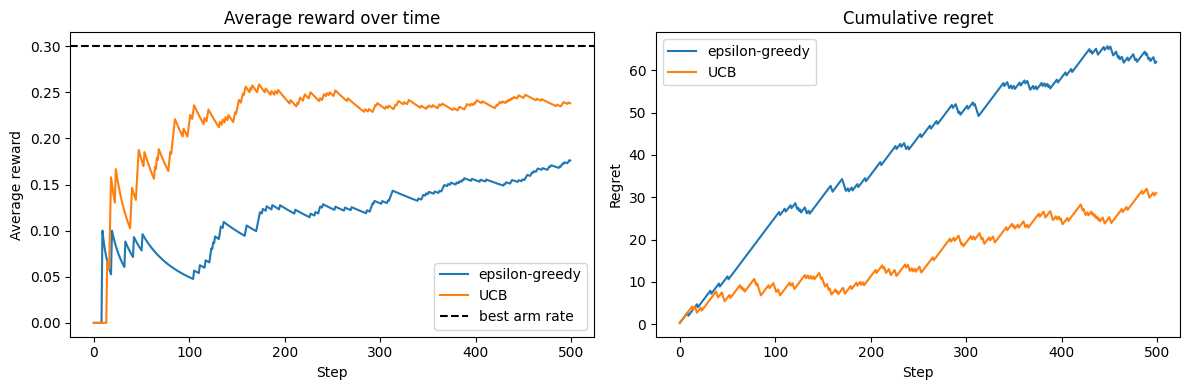

Reflection prompts:
1. Which strategy found the best arm faster?
2. Which strategy accumulated less regret?
3. Why might UCB outperform epsilon-greedy in this setup?


In [5]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def cumulative_average(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)


def cumulative_regret(true_best_reward, rewards):
    return np.cumsum(true_best_reward - rewards)


best_possible = np.max(bandit.true_rewards)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cumulative_average(rewards_eg), label="epsilon-greedy")
plt.plot(cumulative_average(rewards_ucb), label="UCB")
plt.axhline(best_possible, linestyle="--", color="black", label="best arm rate")
plt.title("Average reward over time")
plt.xlabel("Step")
plt.ylabel("Average reward")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cumulative_regret(best_possible, rewards_eg), label="epsilon-greedy")
plt.plot(cumulative_regret(best_possible, rewards_ucb), label="UCB")
plt.title("Cumulative regret")
plt.xlabel("Step")
plt.ylabel("Regret")
plt.legend()
plt.tight_layout()
plt.show()

print("Reflection prompts:")
print("1. Which strategy found the best arm faster?")
print("2. Which strategy accumulated less regret?")
print("3. Why might UCB outperform epsilon-greedy in this setup?")

## Submission

**Total: 100 points**

Real-world: A/B testing, ad optimization, recommendation systems

## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Netflix shows different thumbnails to different users and picks the best one using Thompson Sampling — same as this example
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


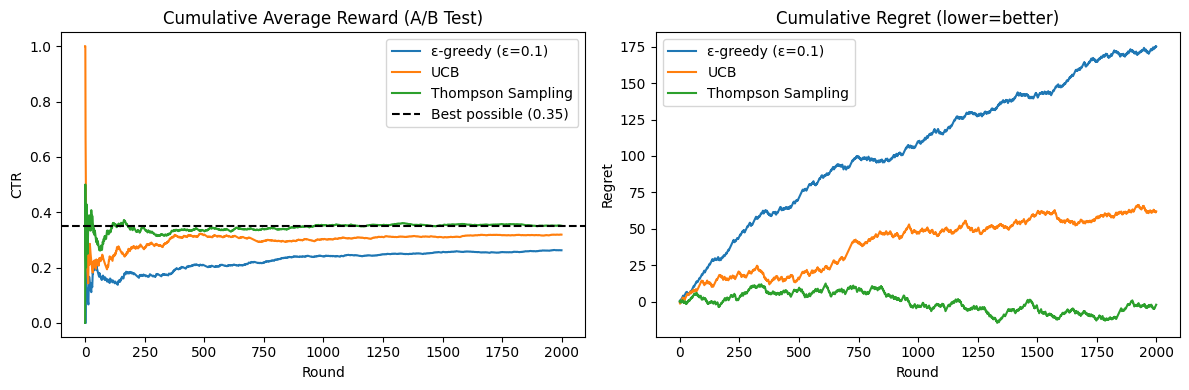


Total rewards — ε-greedy: 525, UCB: 638, Thompson: 702


In [6]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np, matplotlib.pyplot as plt

np.random.seed(42)
# ── Scenario: 5 website variants (like Netflix thumbnails)
# True click-through rates (unknown to agent)
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]   # Variant 3 is best (35%)
N_ARMS   = len(TRUE_RATES)
N_ROUNDS = 2000

def pull(arm): return 1 if np.random.rand() < TRUE_RATES[arm] else 0

def epsilon_greedy(eps):
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    for t in range(N_ROUNDS):
        arm = np.random.randint(N_ARMS) if np.random.rand()<eps else np.argmax(totals/(counts+1e-9))
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    return rewards

def ucb():
    counts = np.zeros(N_ARMS); totals = np.zeros(N_ARMS); rewards = []
    for arm in range(N_ARMS): r=pull(arm); counts[arm]=1; totals[arm]+=r; rewards.append(r)
    for t in range(N_ARMS, N_ROUNDS):
        ucb_vals = totals/counts + np.sqrt(2*np.log(t+1)/counts)
        arm = np.argmax(ucb_vals)
        r = pull(arm); counts[arm]+=1; totals[arm]+=r; rewards.append(r)
    return rewards

def thompson():
    alpha = np.ones(N_ARMS); beta_ = np.ones(N_ARMS); rewards = []
    for _ in range(N_ROUNDS):
        samples = np.random.beta(alpha, beta_)
        arm = np.argmax(samples)
        r = pull(arm)
        if r: alpha[arm]+=1
        else: beta_[arm]+=1
        rewards.append(r)
    return rewards

strategies = {
    'ε-greedy (ε=0.1)': epsilon_greedy(0.1),
    'UCB':               ucb(),
    'Thompson Sampling': thompson(),
}

def cumavg(lst): return np.cumsum(lst) / np.arange(1,len(lst)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for name, r in strategies.items():
    plt.plot(cumavg(r), label=name)
plt.axhline(max(TRUE_RATES), color='k', linestyle='--', label=f"Best possible ({max(TRUE_RATES)})")
plt.title("Cumulative Average Reward (A/B Test)"); plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend()
plt.subplot(1,2,2)
for name, r in strategies.items():
    regret = np.cumsum([max(TRUE_RATES)-pull(np.argmax(TRUE_RATES)) for _ in r]) - np.cumsum(r) + np.cumsum([pull(np.argmax(TRUE_RATES)) for _ in r])
    regret_simple = np.cumsum(max(TRUE_RATES) - np.array(r))
    plt.plot(regret_simple, label=name)
plt.title("Cumulative Regret (lower=better)"); plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend()
plt.tight_layout(); plt.show()
print(f"\nTotal rewards — ε-greedy: {sum(strategies['ε-greedy (ε=0.1)'])}, UCB: {sum(strategies['UCB'])}, Thompson: {sum(strategies['Thompson Sampling'])}")

## 📚 References & Further Reading

**Book:** Sutton & Barto — [RL Introduction Ch.2: Multi-armed Bandits](http://incompleteideas.net/book/the-book-2nd.html)
**Paper:** Auer et al. (2002) — [Finite-time Analysis of UCB](https://link.springer.com/article/10.1023/A:1013689704352)

**Real-World Usage:**
- Google uses Thompson Sampling in Google Ads for A/B testing at scale
- Netflix uses bandit algorithms to pick which thumbnail to show each user

**State-of-the-Art:** ε-greedy and UCB are still dominant in industry A/B testing systems.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


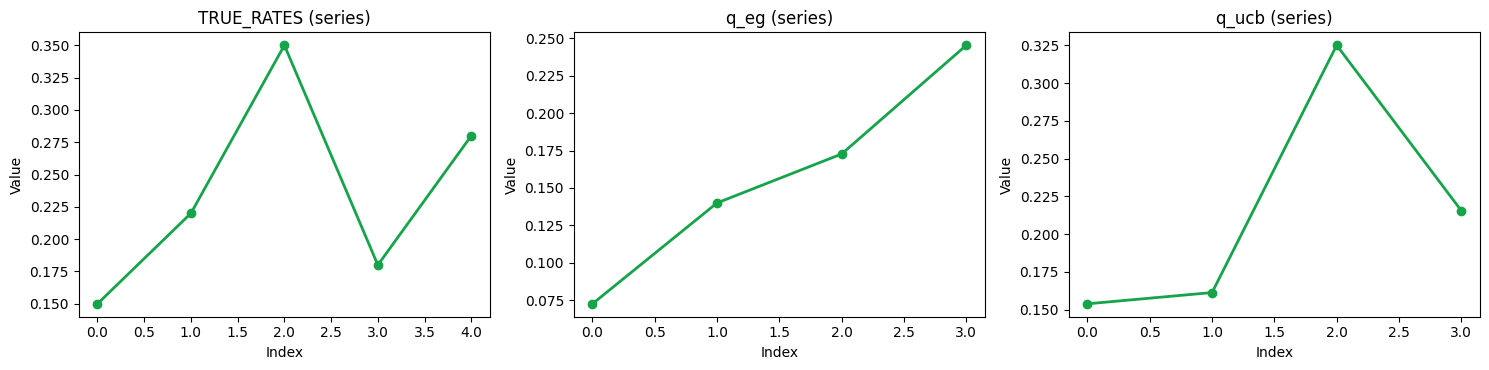

In [7]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can reason about exploration choices and justify them instead of memorizing method names.

**If students remember one idea:** The goal is not to list strategies, but to defend when and why a strategy fits a task.

**Quick check before moving on:**
- Can you explain why your chosen exploration method suits the scenario?
- Can you compare two methods in terms of risk, uncertainty, and data efficiency?

**Bridge to the next step:** After this exercise, students are ready to examine real applications and advanced RL structures in Unit 5.
